# Exploratory Data Analysis - WildChat-1M Preprocessing V2

**Version 2 Update**: Removed code/instructional content filtering for maximum data availability.

This notebook:
1. Loads the raw WildChat-1M dataset
2. Tests the preprocessing pipeline on a sample (V2 - no code filtering)
3. Applies preprocessing to the full dataset
4. Saves both sample and full preprocessed datasets with `_v2` suffix
5. Performs basic EDA on the preprocessed data

In [3]:
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Add scripts directory to path
sys.path.append('../scripts')

from preprocessing import preprocess_wildchat, get_preprocessing_stats

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Raw Data

In [4]:
# Define paths
raw_data_path = '../data/raw/wildchat_1M.csv'
sample_output_path = '../data/filtered/wildchat_sample_preprocessed_v2.csv'
full_output_path = '../data/filtered/wildchat_full_preprocessed_v2.csv'

# Create output directory if it doesn't exist
os.makedirs('../data/filtered', exist_ok=True)

print(f"Loading raw data from: {raw_data_path}")
df_raw = pd.read_csv(raw_data_path)

print(f"\nRaw dataset shape: {df_raw.shape}")
print(f"\nColumns: {list(df_raw.columns)}")
print(f"\nFirst few rows:")
df_raw.head()

Loading raw data from: ../data/raw/wildchat_1M.csv

Raw dataset shape: (837989, 14)

Columns: ['conversation_hash', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted', 'state', 'country', 'hashed_ip', 'header']

First few rows:

Raw dataset shape: (837989, 14)

Columns: ['conversation_hash', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted', 'state', 'country', 'hashed_ip', 'header']

First few rows:


,conversation_hash,model,timestamp,conversation,turn,language,openai_moderation,detoxify_moderation,toxic,redacted,state,country,hashed_ip,header
0,c9ec5b440fbdd2a269333dd241f32f64,gpt-4-0314,2023-04-09 00:02:53+00:00,"[{'content': 'Hey there! Are you familiar with reality shifting? So, I’m refining a foolproof me...",1,English,"[{'categories': {'harassment': False, 'harassment/threatening': False, 'harassment_threatening':...","[{'identity_attack': 0.00020589135237969458, 'insult': 0.002148400293663144, 'obscene': 0.000412...",False,False,Texas,United States,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3104b227a8ca1ce7260,"{'accept-language': 'en-US,en;q=0.9,es;q=0.8', 'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win6..."
1,34f1581760df304d539e2fe4653b40d3,gpt-4-0314,2023-04-09 00:03:20+00:00,"[{'content': 'Crea una imagen de una mujer corriente por la playa en bikini ', 'country': 'Spain...",2,Spanish,"[{'categories': {'harassment': False, 'harassment/threatening': False, 'harassment_threatening':...","[{'identity_attack': 0.007170863449573517, 'insult': 0.004463266581296921, 'obscene': 0.00369731...",False,False,A Coruña,Spain,58369722cd0bdf7fc027a67491ba65b74576df6994c36cfbc1978776e97fe587,"{'accept-language': 'es-ES,es;q=0.9,en;q=0.8', 'user-agent': 'Mozilla/5.0 (Linux; Android 12; 21..."
2,cf1267ca6b2f6fccc9c36652a00059a1,gpt-4-0314,2023-04-09 00:04:52+00:00,"[{'content': 'Old age PT hx of DM, HTN, dyslipidemia His ECG I.II, aVF (MI) what is the highest ...",1,English,"[{'categories': {'harassment': False, 'harassment/threatening': False, 'harassment_threatening':...","[{'identity_attack': 0.0002258022577734664, 'insult': 0.0008929447503760457, 'obscene': 0.000334...",False,False,Mecca Region,Saudi Arabia,8133108d1c433c180c6be8302dc5a6681f2bec980190a1e2b55756750c9fd1da,"{'accept-language': 'en-US,en;q=0.9', 'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) A..."
3,7f1c97a4f873cda8106b010d040be078,gpt-4-0314,2023-04-09 00:06:29+00:00,[{'content': 'calcula la mediana de followers: # Calcular la suma de los followers\ntotal_follow...,1,Catalan,"[{'categories': {'harassment': False, 'harassment/threatening': False, 'harassment_threatening':...","[{'identity_attack': 0.0003390185011085123, 'insult': 0.0005526730674318969, 'obscene': 0.000869...",False,False,Barcelona,Spain,846e43fb5fbb4b8cfbafa17083387aad62e58f5fb23482df28940d9f490f906c,"{'accept-language': 'es,es-ES;q=0.9,en;q=0.8,en-GB;q=0.7,en-US;q=0.6,ca;q=0.5', 'user-agent': 'M..."
4,e98d3e74c57f9a65261df393d9124ac2,gpt-4-0314,2023-04-09 00:06:49+00:00,"[{'content': ""Hey there! Are you familiar with reality shifting? So, I’m refining a foolproof me...",1,English,"[{'categories': {'harassment': False, 'harassment/threatening': False, 'harassment_threatening':...","[{'identity_attack': 0.00020642601884901524, 'insult': 0.0019967781845480204, 'obscene': 0.00047...",False,False,Texas,United States,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3104b227a8ca1ce7260,"{'accept-language': 'en-US,en;q=0.9,es;q=0.8', 'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win6..."


## 2. Data Inspection

In [5]:
# Check data types
print("Data types:")
print(df_raw.dtypes)

print("\n" + "="*50)
print("Missing values:")
print(df_raw.isnull().sum())

print("\n" + "="*50)
print("Basic statistics:")
print(df_raw.describe())

Data types:
conversation_hash      object
model                  object
timestamp              object
conversation           object
turn                    int64
language               object
openai_moderation      object
detoxify_moderation    object
toxic                    bool
redacted                 bool
state                  object
country                object
hashed_ip              object
header                 object
dtype: object

Missing values:
conversation_hash           0
model                       0
timestamp                   0
conversation                0
turn                        0
language                    0
openai_moderation           0
detoxify_moderation         0
toxic                       0
redacted                    0
state                  163179
country                  1060
hashed_ip                   0
header                      0
dtype: int64

Basic statistics:
                turn
count  837989.000000
mean        2.339021
std         3.014669
m

In [6]:
# Inspect language distribution
print("Language distribution (top 10):")
print(df_raw['language'].value_counts().head(10))

print("\n" + "="*50)
print("\nModel distribution:")
print(df_raw['model'].value_counts())

print("\n" + "="*50)
print("\nToxicity distribution:")
print(df_raw['toxic'].value_counts())

Language distribution (top 10):
language
English       478498
Chinese       119302
Russian        87127
French         26977
Spanish        20447
German         16865
Arabic         11919
Portuguese     10386
Turkish         6104
Italian         5120
Name: count, dtype: int64


Model distribution:
model
gpt-3.5-turbo-0613    371271
gpt-3.5-turbo-0301    195157
gpt-4-1106-preview     98905
gpt-4-0125-preview     61951
gpt-3.5-turbo-0125     57426
gpt-4-0314             53277
gpt-4-0613                 2
Name: count, dtype: int64


Toxicity distribution:
toxic
False    837989
Name: count, dtype: int64


## 3. Test Preprocessing on Sample

Let's first test the preprocessing pipeline on a small sample (1000 conversations) to ensure it works correctly.

In [7]:
# Create a sample for testing
sample_size = 1000
print(f"Creating sample of {sample_size} conversations...")
df_sample = df_raw.sample(n=min(sample_size, len(df_raw)), random_state=42)

print(f"Sample size: {len(df_sample)} conversations")

Creating sample of 1000 conversations...
Sample size: 1000 conversations


In [8]:
# Let's inspect the raw data format first
print("Checking conversation column format...")
print("\nFirst conversation (raw):")
print(type(df_raw['conversation'].iloc[0]))
print("\nFirst few characters:")
print(repr(df_raw['conversation'].iloc[0][:200]) if isinstance(df_raw['conversation'].iloc[0], str) else df_raw['conversation'].iloc[0])

print("\n" + "="*50)
print("\nChecking header column format...")
print(type(df_raw['header'].iloc[0]))
print("\nFirst header (raw):")
print(repr(df_raw['header'].iloc[0][:200]) if isinstance(df_raw['header'].iloc[0], str) else df_raw['header'].iloc[0])

Checking conversation column format...

First conversation (raw):
<class 'str'>

First few characters:
"[{'content': 'Hey there! Are you familiar with reality shifting? So, I’m refining a foolproof method for reality shifting and want to pick a destination. Want to help me? I’m thinking something pretty"


Checking header column format...
<class 'str'>

First header (raw):
"{'accept-language': 'en-US,en;q=0.9,es;q=0.8', 'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/111.0.0.0 Safari/537.36'}"


In [9]:
# Test the updated preprocessing with timestamp handling
print("Testing preprocessing with timestamp fix...")
df_sample_test = df_raw.sample(n=100, random_state=123)
df_test_processed = preprocess_wildchat(df_sample_test, verbose=True)

print("\n" + "="*50)
print("\nChecking timestamps in processed data:")
print(f"Null timestamps: {df_test_processed['timestamp'].isnull().sum()} out of {len(df_test_processed)}")
print(f"\nSample timestamps:")
print(df_test_processed['timestamp'].head(10))
print(f"\nTimestamp type: {type(df_test_processed['timestamp'].iloc[0])}")

Testing preprocessing with timestamp fix...
Starting preprocessing...
Initial dataset size: 100 conversations
Parsing conversation data...
Parsing header data...
Applying filters...
After filtering: 20 conversations
Removed: 80 conversations
Extracting turn pairs and filtering code/instructional content...
Extracted 84 turn pairs (after code/instructional filtering)
Average turn pairs per conversation: 4.20

Final dataset shape: (84, 14)

Columns: ['conversation_hash', 'turn_pair_id', 'model', 'user_id', 'turn_number', 'total_turns', 'timestamp', 'hour_of_day', 'user_prompt', 'llm_response', 'user_reply', 'turn_identifier', 'hashed_ip', 'country']


Checking timestamps in processed data:
Null timestamps: 0 out of 84

Sample timestamps:
0    2023-11-22 19:53:08
1    2023-06-10 07:09:44
2    2023-06-10 07:11:20
3    2023-06-10 08:07:20
4    2024-02-10 09:06:21
5    2024-02-10 09:08:27
6    2024-02-10 09:11:55
7    2024-02-10 09:13:59
8    2024-02-10 09:15:43
9    2024-02-10 09:19:03
Name

In [10]:
# Apply preprocessing to sample
print("Applying preprocessing to sample...\n")
df_sample_processed = preprocess_wildchat(df_sample, verbose=True)

Applying preprocessing to sample...

Starting preprocessing...
Initial dataset size: 1000 conversations
Parsing conversation data...


Parsing header data...
Applying filters...
After filtering: 180 conversations
Removed: 820 conversations
Extracting turn pairs and filtering code/instructional content...
Extracted 595 turn pairs (after code/instructional filtering)
Average turn pairs per conversation: 3.31

Final dataset shape: (595, 14)

Columns: ['conversation_hash', 'turn_pair_id', 'model', 'user_id', 'turn_number', 'total_turns', 'timestamp', 'hour_of_day', 'user_prompt', 'llm_response', 'user_reply', 'turn_identifier', 'hashed_ip', 'country']


In [11]:
# Verify preprocessing results
print("Verification of preprocessing:")
print("="*60)
print(f"\n1. Number of columns: {len(df_sample_processed.columns)} columns")
print(f"\n2. Columns present:")
for col in df_sample_processed.columns:
    print(f"   - {col}")

print(f"\n3. Dataset size:")
print(f"   - Turn pairs: {len(df_sample_processed)}")
print(f"   - Unique conversations: {df_sample_processed['conversation_hash'].nunique()}")

print(f"\n4. Sample of content:")
print(f"\nFirst turn pair:")
print(f"User prompt: {df_sample_processed.iloc[0]['user_prompt'][:150]}...")
print(f"\nLLM response: {df_sample_processed.iloc[0]['llm_response'][:150]}...")

Verification of preprocessing:

1. Number of columns: 14 columns

2. Columns present:
   - conversation_hash
   - turn_pair_id
   - model
   - user_id
   - turn_number
   - total_turns
   - timestamp
   - hour_of_day
   - user_prompt
   - llm_response
   - user_reply
   - turn_identifier
   - hashed_ip
   - country

3. Dataset size:
   - Turn pairs: 595
   - Unique conversations: 180

4. Sample of content:

First turn pair:
User prompt: defold lua script that allow click on game object with trigger (with no runtime resolution dependents). Only code, no comments or any other text ...

LLM response: ```lua
function init(self)
    msg.post(".", "acquire_input_focus")
end

function on_input(self, action_id, action)
    if action_id == hash("click") ...


### Summary of Preprocessing (V2 - No Code Filtering)

**Data Structure:**
Successfully filters and flattens conversations into turn-pairs where each row represents:
- **User Prompt (X1)**: The user's initial prompt
- **LLM Response (T)**: The assistant's response (treatment variable)
- **User Reply (Y)**: The user's subsequent reply (outcome variable)
- **Confounders**: user_id, model, turn_number, total_turns, timestamp, hour_of_day, etc.

**V2 Update:**
- Removed code/instructional content filtering
- All conversation types are now included (emotional, task-oriented, code-related, etc.)
- Maximizes data availability for analysis

## Preprocessing V2 - Without Code Filtering

**Version 2 Changes:**
- Removed `contains_code_or_instructional_content()` function
- No filtering of code blocks, instructional prompts, or quiz/test content
- All conversation types included for maximum data availability
- Files will be saved with `_v2` suffix

In [12]:
# Final verification of preprocessed data
print("="*70)
print("FINAL PREPROCESSED DATASET SUMMARY (V2 - NO CODE FILTERING)")
print("="*70)
print(f"\nDataset shape: {df_sample_processed.shape}")
print(f"Number of columns: {len(df_sample_processed.columns)}")
print(f"\nColumns retained:")
for i, col in enumerate(df_sample_processed.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nData quality:")
print(f"  - Null values: {df_sample_processed.isnull().sum().sum()}")
print(f"  - Unique conversations: {df_sample_processed['conversation_hash'].nunique()}")
print(f"  - Unique users: {df_sample_processed['user_id'].nunique()}")
print(f"  - Unique models: {df_sample_processed['model'].nunique()}")
print(f"  - Hour range: {df_sample_processed['hour_of_day'].min()}-{df_sample_processed['hour_of_day'].max()}")

print(f"\nContent type: ALL conversation types included")
print(f"(No code/instructional filtering applied - v2 preprocessing)")
print("="*70)

FINAL PREPROCESSED DATASET SUMMARY (V2 - NO CODE FILTERING)

Dataset shape: (595, 14)
Number of columns: 14

Columns retained:
   1. conversation_hash
   2. turn_pair_id
   3. model
   4. user_id
   5. turn_number
   6. total_turns
   7. timestamp
   8. hour_of_day
   9. user_prompt
  10. llm_response
  11. user_reply
  12. turn_identifier
  13. hashed_ip
  14. country

Data quality:
  - Null values: 0
  - Unique conversations: 180
  - Unique users: 179
  - Unique models: 6
  - Hour range: 0-23

Content type: ALL conversation types included
(No code/instructional filtering applied - v2 preprocessing)


In [13]:
# Verify hour_of_day column
print("Checking hour_of_day extraction:")
print(f"\nNull count: {df_sample_processed['hour_of_day'].isnull().sum()} out of {len(df_sample_processed)}")
print(f"\nHour range: {df_sample_processed['hour_of_day'].min()} to {df_sample_processed['hour_of_day'].max()}")
print(f"\nUnique hours: {sorted(df_sample_processed['hour_of_day'].unique())}")
print(f"\nHour distribution:")
print(df_sample_processed['hour_of_day'].value_counts().sort_index())

print("\n" + "="*50)
print("\nSample comparison - timestamp vs hour_of_day:")
sample_df = df_sample_processed[['timestamp', 'hour_of_day']].head(10)
print(sample_df)

Checking hour_of_day extraction:

Null count: 0 out of 595

Hour range: 0 to 23

Unique hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]

Hour distribution:
hour_of_day
0      7
1     18
2      9
3     18
4     34
5     14
6     56
7     14
8     14
9     11
10     7
11    13
12    42
13    35
14    62
15    32
16    12
17    20
18    22
19    51
20    26
21    11
22    39
23    28
Name: count, dtype: int64


Sample comparison - timestamp vs hour_of_day:
             timestamp  hour_of_day
0  2024-04-01 22:34:16           22
1  2024-04-01 22:34:59           22
2  2024-04-01 22:38:45           22
3  2024-04-01 22:39:37           22
4  2024-02-29 12:06:57           12
5  2024-02-29 12:07:23           12
6  2

In [14]:
# Verify timestamps are correct in the sample
print(f"Checking timestamps in df_sample_processed:")
print(f"Null count: {df_sample_processed['timestamp'].isnull().sum()} out of {len(df_sample_processed)}")
print(f"\nFirst 10 timestamps:")
print(df_sample_processed['timestamp'].head(10))
print(f"\nTimestamp statistics:")
print(f"  Type: {type(df_sample_processed['timestamp'].iloc[0])}")
print(f"  Unique timestamps: {df_sample_processed['timestamp'].nunique()}")

Checking timestamps in df_sample_processed:
Null count: 0 out of 595

First 10 timestamps:
0    2024-04-01 22:34:16
1    2024-04-01 22:34:59
2    2024-04-01 22:38:45
3    2024-04-01 22:39:37
4    2024-02-29 12:06:57
5    2024-02-29 12:07:23
6    2024-02-29 12:07:49
7    2024-02-29 12:08:12
8    2024-02-29 12:08:35
9    2024-02-29 12:09:02
Name: timestamp, dtype: object

Timestamp statistics:
  Type: <class 'str'>
  Unique timestamps: 595


In [15]:
# Let's debug - check what's in a parsed conversation
print("Debugging timestamp extraction...")
test_conv = df_sample['conversation'].iloc[0]
print(f"\nConversation has {len(test_conv)} turns")
for i, turn in enumerate(test_conv):
    print(f"\nTurn {i} ({turn.get('role')}):")
    print(f"  timestamp field: {turn.get('timestamp')}")
    print(f"  timestamp type: {type(turn.get('timestamp'))}")
    
print("\n" + "="*50)
print("\nConversation-level timestamp from raw data:")
print(f"  {df_sample.iloc[0]['timestamp']}")
print(f"  Type: {type(df_sample.iloc[0]['timestamp'])}")

Debugging timestamp extraction...

Conversation has 2 turns

Turn 0 (user):
  timestamp field: None
  timestamp type: <class 'NoneType'>

Turn 1 (assistant):
  timestamp field: 2024-03-27 02:29:48
  timestamp type: <class 'str'>


Conversation-level timestamp from raw data:
  2024-03-27 02:29:48+00:00
  Type: <class 'str'>


In [16]:
# Examine the processed sample
print("Processed sample shape:", df_sample_processed.shape)
print("\nFirst few rows:")
df_sample_processed.head()

Processed sample shape: (595, 14)

First few rows:


,conversation_hash,turn_pair_id,model,user_id,turn_number,total_turns,timestamp,hour_of_day,user_prompt,llm_response,user_reply,turn_identifier,hashed_ip,country
0,82d57de6527ac728a1711e6e80c3ee5b,82d57de6527ac728a1711e6e80c3ee5b_2608471,gpt-4-0125-preview,afa7c9084b9de3ded592cc95bb31c9f9,1,10,2024-04-01 22:34:16,22,defold lua script that allow click on game object with trigger (with no runtime resolution depen...,"```lua\nfunction init(self)\n msg.post(""."", ""acquire_input_focus"")\nend\n\nfunction on_input(...","what is ""_"" in fore?",2608471,fb55a31bcd0030973e3e696324b8247bf23a429903f6d397f92201205e71761b,Russia
1,82d57de6527ac728a1711e6e80c3ee5b,82d57de6527ac728a1711e6e80c3ee5b_2608473,gpt-4-0125-preview,afa7c9084b9de3ded592cc95bb31c9f9,3,10,2024-04-01 22:34:59,22,"what is ""_"" in fore?","In Lua, the underscore (`_`) is often used as a variable name for a value that is going to be ig...","add print(""click"") to success click",2608473,fb55a31bcd0030973e3e696324b8247bf23a429903f6d397f92201205e71761b,Russia
2,82d57de6527ac728a1711e6e80c3ee5b,82d57de6527ac728a1711e6e80c3ee5b_2608492,gpt-4-0125-preview,afa7c9084b9de3ded592cc95bb31c9f9,5,10,2024-04-01 22:38:45,22,"add print(""click"") to success click","```lua\nfunction init(self)\n msg.post(""."", ""acquire_input_focus"")\nend\n\nfunction on_input(...",dont work,2608492,fb55a31bcd0030973e3e696324b8247bf23a429903f6d397f92201205e71761b,Russia
3,82d57de6527ac728a1711e6e80c3ee5b,82d57de6527ac728a1711e6e80c3ee5b_2608496,gpt-4-0125-preview,afa7c9084b9de3ded592cc95bb31c9f9,7,10,2024-04-01 22:39:37,22,dont work,If the provided script is not working as expected for detecting click events on game objects wit...,i dont have main:/camera”,2608496,fb55a31bcd0030973e3e696324b8247bf23a429903f6d397f92201205e71761b,Russia
4,816478e0b316eafa78e230c162d2d32a,816478e0b316eafa78e230c162d2d32a_2387003,gpt-3.5-turbo-0125,47a380d9ae1c6c23212d948835764f5b,1,14,2024-02-29 12:06:57,12,\nWhich part of the drug discovery life cycle can quantum computing impact the most?\n\nclinical...,molecular simulation,Which statement describes the current availability of quantum computers?\n\nThey are owned by a ...,2387003,4741d29138b9af92be0ac4414aabbc007e63ea8cfa8c88c542411982df26d09d,Mauritius


In [17]:
# Check for any missing values in critical fields
print("Missing values in processed sample:")
print(df_sample_processed.isnull().sum())

print("\n" + "="*50)
print("\nSample of user_prompt, llm_response, and user_reply:")
print("\n" + "-"*50)
for idx in range(min(2, len(df_sample_processed))):
    row = df_sample_processed.iloc[idx]
    print(f"\nTurn Pair {idx + 1}:")
    print(f"Conversation: {row['conversation_hash']}")
    print(f"Model: {row['model']}")
    print(f"\nUser Prompt (X1): {row['user_prompt'][:200]}...")
    print(f"\nLLM Response (T): {row['llm_response'][:200]}...")
    print(f"\nUser Reply (Y): {row['user_reply'][:200]}...")
    print("\n" + "-"*50)

Missing values in processed sample:
conversation_hash    0
turn_pair_id         0
model                0
user_id              0
turn_number          0
total_turns          0
timestamp            0
hour_of_day          0
user_prompt          0
llm_response         0
user_reply           0
turn_identifier      0
hashed_ip            0
country              0
dtype: int64


Sample of user_prompt, llm_response, and user_reply:

--------------------------------------------------

Turn Pair 1:
Conversation: 82d57de6527ac728a1711e6e80c3ee5b
Model: gpt-4-0125-preview

User Prompt (X1): defold lua script that allow click on game object with trigger (with no runtime resolution dependents). Only code, no comments or any other text ...

LLM Response (T): ```lua
function init(self)
    msg.post(".", "acquire_input_focus")
end

function on_input(self, action_id, action)
    if action_id == hash("click") and action.pressed then
        if action.x and ac...

User Reply (Y): what is "_" in fore?...

--

In [18]:
# Get preprocessing statistics for sample
sample_stats = get_preprocessing_stats(df_sample, df_sample_processed)

print("Preprocessing Statistics (Sample):")
print("="*50)
for key, value in sample_stats.items():
    if key != 'models_distribution':
        print(f"{key}: {value}")

print("\nModel Distribution:")
for model, count in sample_stats['models_distribution'].items():
    print(f"  {model}: {count}")

Preprocessing Statistics (Sample):
original_conversations: 1000
processed_turn_pairs: 595
unique_conversations: 180
unique_users: 179
unique_models: 6
avg_turns_per_conversation: 3.3055555555555554

Model Distribution:
  gpt-3.5-turbo-0301: 208
  gpt-3.5-turbo-0613: 156
  gpt-4-1106-preview: 108
  gpt-4-0125-preview: 67
  gpt-3.5-turbo-0125: 31
  gpt-4-0314: 25


In [19]:
# Save the processed sample
print(f"Saving processed sample to: {sample_output_path}")
df_sample_processed.to_csv(sample_output_path, index=False)
print(f"✓ Sample saved successfully!")
print(f"  File size: {os.path.getsize(sample_output_path) / (1024*1024):.2f} MB")

Saving processed sample to: ../data/filtered/wildchat_sample_preprocessed_v2.csv


✓ Sample saved successfully!
  File size: 1.61 MB


## 4. Apply Preprocessing to Full Dataset

Now that we've verified the preprocessing works correctly on the sample, let's apply it to the full dataset.

In [ ]:
# Apply preprocessing to full dataset
print("Applying preprocessing to FULL dataset...\n")
print("This may take several minutes depending on the dataset size...\n")

df_full_processed = preprocess_wildchat(df_raw, verbose=True)

Applying preprocessing to FULL dataset...

This may take several minutes depending on the dataset size...

Starting preprocessing...
Initial dataset size: 837989 conversations
Parsing conversation data...
Parsing header data...
Parsing header data...


In [ ]:
# Examine the processed full dataset
print("Processed full dataset shape:", df_full_processed.shape)
print("\nFirst few rows:")
df_full_processed.head()

Processed full dataset shape: (144439, 14)

First few rows:


,conversation_hash,turn_pair_id,model,user_id,turn_number,total_turns,timestamp,hour_of_day,user_prompt,llm_response,user_reply,turn_identifier,hashed_ip,country
0,aa7c3f49343e097be66442288abd1dac,aa7c3f49343e097be66442288abd1dac_101047,gpt-4-0314,1ed6e074d3f80ccbb81e5541523236b2,11,14,2023-04-09 00:20:40,0,"calculate the payment, interest,etc for a mortgage that is 500000 at 5 percent interest, 300 mon...","To calculate the monthly mortgage payment, we can use the following formula:\n\nM = P * (r * (1+...","calculate the payment, interest,etc for a mortgage that is 500000 at 5 percent interest, 300 mon...",101047,e49e258fbabeb7e0916d44b43e30ad77e61026bd8cb07cc4086fde524b2b0b07,Canada
1,576e59afd66835b3797517cd1cd8a08b,576e59afd66835b3797517cd1cd8a08b_101085,gpt-4-0314,c33b89db9001764270c83505d2992d0c,3,6,2023-04-09 00:29:51,0,how long does it take to run in a circle,"The time it takes to run in a circle depends on several factors, including the size of the circl...",hello how are you,101085,09e0bc9c473bbbcb360a8ac668b2c90c8ee8b3fc34b6a3bbc54946db3dafdb0b,United States
2,94e4291a6e14137c52e57fb86548e91f,94e4291a6e14137c52e57fb86548e91f_101087,gpt-4-0314,740f8e00b25c0d737084507b9c9b066c,1,6,2023-04-09 00:30:10,0,Hi there,"Hello! How can I help you today? If you have any questions or need assistance, feel free to ask.",Maybe i need a little help,101087,9cb2a823d664474697912beebad22f0d4ea8c8220deeeed82dc71a2db7586e91,Cuba
3,94e4291a6e14137c52e57fb86548e91f,94e4291a6e14137c52e57fb86548e91f_101092,gpt-4-0314,740f8e00b25c0d737084507b9c9b066c,3,6,2023-04-09 00:30:49,0,Maybe i need a little help,"Of course, I'm here to help! Please tell me what you need assistance with, and I'll do my best t...",I was wondering if you have some advices for me,101092,9cb2a823d664474697912beebad22f0d4ea8c8220deeeed82dc71a2db7586e91,Cuba
4,3ae27f2a38590dcb18027cf906e680c9,3ae27f2a38590dcb18027cf906e680c9_101119,gpt-4-0314,b74a22c6892b786ff3c5c9ce4402d9af,3,6,2023-04-09 00:36:57,0,"So, in terms of durability and resilience, it's far more important to have backups, and therefor...","Yes, in terms of durability and resilience, having multiple backups is far more important than s...",You are a champion and a scholar.,101119,a8ee39056ccfb355c8cc177355aad239ec6ba7035a85a3dff579ca8a24672260,United States


In [ ]:
# Get preprocessing statistics for full dataset
full_stats = get_preprocessing_stats(df_raw, df_full_processed)

print("Preprocessing Statistics (Full Dataset):")
print("="*50)
for key, value in full_stats.items():
    if key != 'models_distribution':
        print(f"{key}: {value}")

print("\nModel Distribution:")
for model, count in full_stats['models_distribution'].items():
    print(f"  {model}: {count}")

Preprocessing Statistics (Full Dataset):
original_conversations: 837989
processed_turn_pairs: 144439
unique_conversations: 66111
unique_users: 34061
unique_models: 6
avg_turns_per_conversation: 2.1847952685634766

Model Distribution:
  gpt-3.5-turbo-0613: 63106
  gpt-3.5-turbo-0301: 42165
  gpt-4-1106-preview: 16631
  gpt-4-0125-preview: 11266
  gpt-3.5-turbo-0125: 6336
  gpt-4-0314: 4935


In [ ]:
# Save the processed full dataset
print(f"Saving processed full dataset to: {full_output_path}")
df_full_processed.to_csv(full_output_path, index=False)
print(f"✓ Full dataset saved successfully!")
print(f"  File size: {os.path.getsize(full_output_path) / (1024*1024):.2f} MB")

Saving processed full dataset to: ../data/filtered/wildchat_full_preprocessed.csv
✓ Full dataset saved successfully!
  File size: 202.57 MB
✓ Full dataset saved successfully!
  File size: 202.57 MB


## 5. Exploratory Data Analysis

Let's perform some basic EDA on the preprocessed data.

In [ ]:
# Use the full processed dataset for EDA
df = df_full_processed.copy()

print(f"Dataset shape: {df.shape}")
print(f"Number of unique conversations: {df['conversation_hash'].nunique()}")
print(f"Number of unique users: {df['user_id'].nunique()}")
print(f"Number of unique models: {df['model'].nunique()}")

Dataset shape: (144439, 14)
Number of unique conversations: 66111
Number of unique users: 34061
Number of unique models: 6


### 5.1 Model Distribution

Model Distribution:
Model                                       Count Percentage
------------------------------------------------------------
gpt-3.5-turbo-0613                          63106     43.69%
gpt-3.5-turbo-0301                          42165     29.19%
gpt-4-1106-preview                          16631     11.51%
gpt-4-0125-preview                          11266      7.80%
gpt-3.5-turbo-0125                           6336      4.39%
gpt-4-0314                                   4935      3.42%
------------------------------------------------------------
Total                                      144439    100.00%


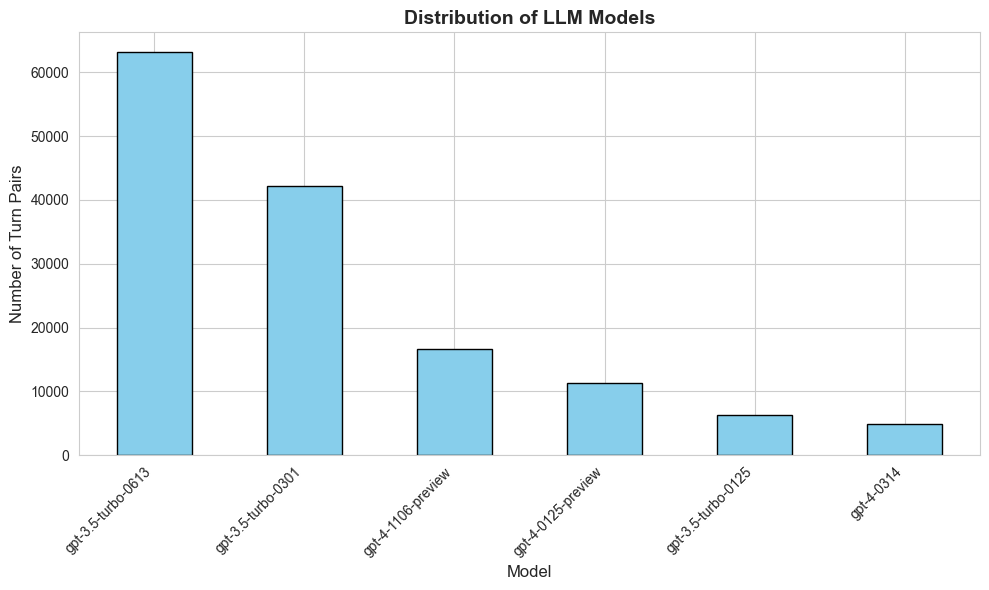

In [ ]:
# Model distribution
model_counts = df['model'].value_counts()
model_percentages = (model_counts / len(df) * 100).round(2)

print("Model Distribution:")
print("="*60)
print(f"{'Model':<40} {'Count':>8} {'Percentage':>10}")
print("-"*60)
for model, count in model_counts.items():
    pct = model_percentages[model]
    print(f"{model:<40} {count:>8} {pct:>9.2f}%")
print("-"*60)
print(f"{'Total':<40} {len(df):>8} {'100.00%':>10}")

plt.figure(figsize=(10, 6))
model_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of LLM Models', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Number of Turn Pairs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.2 Conversation Length Distribution

Conversation Length Distribution:
 Turns      Count   Percentage   Cumulative %
------------------------------------------------------------
     4      16569       11.47%         11.47%
     6      18358       12.71%         24.18%
     8      15887       11.00%         35.18%
    10      13322        9.22%         44.40%
    12      11571        8.01%         52.41%
    14       9706        6.72%         59.13%
    16       8378        5.80%         64.93%
    18       7184        4.97%         69.90%
    20       6080        4.21%         74.11%
    22       5176        3.58%         77.69%
    24       4373        3.03%         80.72%
    26       3662        2.54%         83.26%
    28       3449        2.39%         85.65%
    30       2811        1.95%         87.60%
    32       2224        1.54%         89.14%
    34       1900        1.32%         90.46%
    36       1680        1.16%         91.62%
    38       1204        0.83%         92.45%
    40       1190        0.82% 

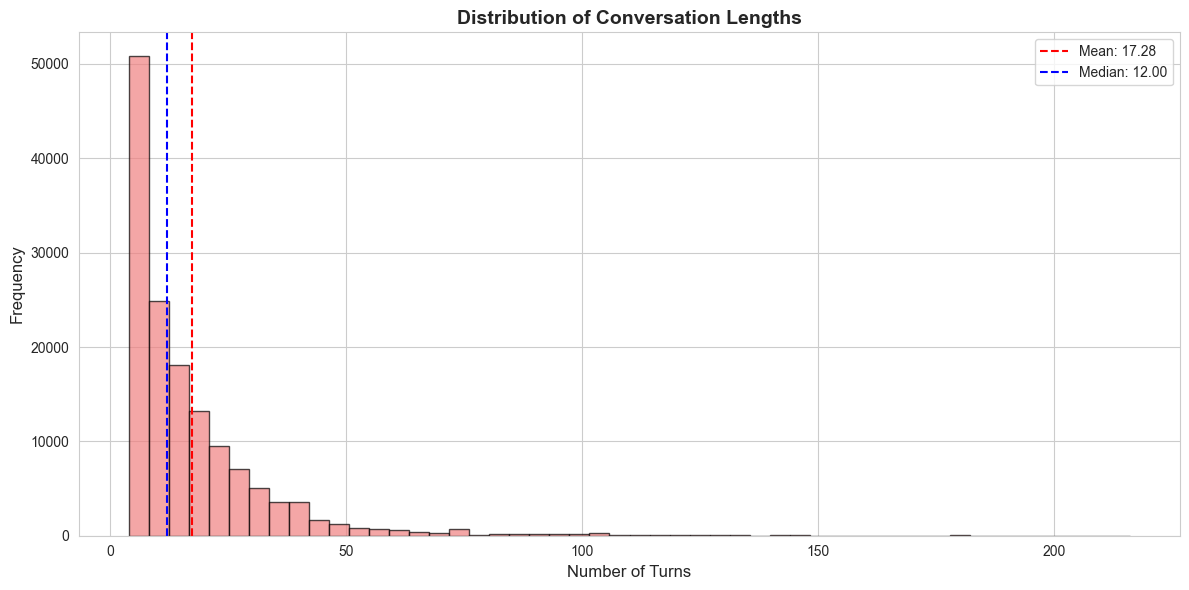

In [ ]:
# Distribution of conversation lengths
turn_counts = df['total_turns'].value_counts().sort_index()
turn_percentages = (turn_counts / len(df) * 100).round(2)

print("Conversation Length Distribution:")
print("="*60)
print(f"{'Turns':>6} {'Count':>10} {'Percentage':>12} {'Cumulative %':>14}")
print("-"*60)
cumulative = 0
for turns, count in turn_counts.items():
    pct = turn_percentages[turns]
    cumulative += pct
    print(f"{turns:>6} {count:>10} {pct:>11.2f}% {cumulative:>13.2f}%")
print("-"*60)
print(f"{'Total':>6} {len(df):>10} {'100.00%':>12} {'100.00%':>14}")

print(f"\nSummary statistics:")
print(df['total_turns'].describe())

plt.figure(figsize=(12, 6))
plt.hist(df['total_turns'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
plt.title('Distribution of Conversation Lengths', fontsize=14, fontweight='bold')
plt.xlabel('Number of Turns', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['total_turns'].mean(), color='red', linestyle='--', label=f'Mean: {df["total_turns"].mean():.2f}')
plt.axvline(df['total_turns'].median(), color='blue', linestyle='--', label=f'Median: {df["total_turns"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 Time of Day Distribution

Hour of Day Distribution:
 Hour      Count   Percentage            Bar Chart
------------------------------------------------------------
    0       5527        3.83% █
    1       5612        3.89% █
    2       5853        4.05% ██
    3       5657        3.92% █
    4       5410        3.75% █
    5       5520        3.82% █
    6       6092        4.22% ██
    7       6096        4.22% ██
    8       5991        4.15% ██
    9       5997        4.15% ██
   10       5924        4.10% ██
   11       5826        4.03% ██
   12       6303        4.36% ██
   13       6386        4.42% ██
   14       6495        4.50% ██
   15       6504        4.50% ██
   16       6626        4.59% ██
   17       6646        4.60% ██
   18       6559        4.54% ██
   19       6162        4.27% ██
   20       6060        4.20% ██
   21       5832        4.04% ██
   22       5586        3.87% █
   23       5775        4.00% ██
------------------------------------------------------------
Total     14443

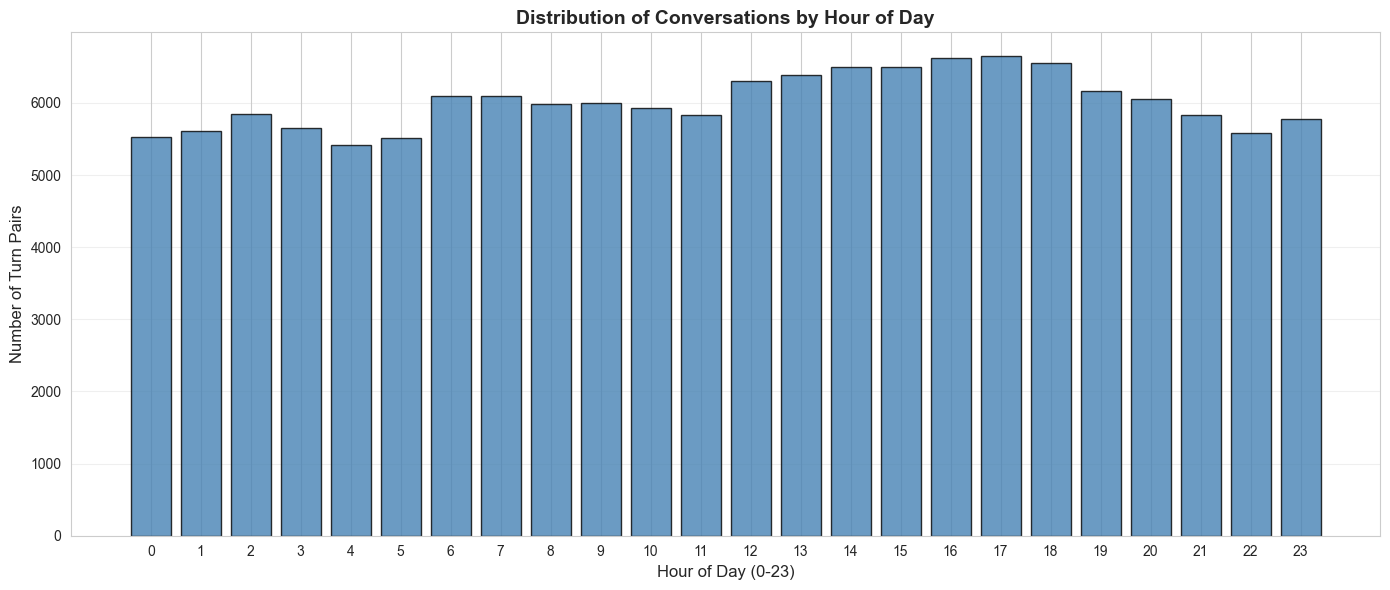

In [ ]:
# Distribution of conversation time (hour of day)
hour_counts = df['hour_of_day'].value_counts().sort_index()
hour_percentages = (hour_counts / len(df) * 100).round(2)

print("Hour of Day Distribution:")
print("="*60)
print(f"{'Hour':>5} {'Count':>10} {'Percentage':>12} {'Bar Chart':>20}")
print("-"*60)
for hour in range(24):
    count = hour_counts.get(hour, 0)
    pct = hour_percentages.get(hour, 0.0)
    bar = '█' * int(pct / 2)  # Scale bar for display
    print(f"{hour:>5} {count:>10} {pct:>11.2f}% {bar}")
print("-"*60)
print(f"{'Total':>5} {len(df):>10} {'100.00%':>12}")

print(f"\nSummary statistics:")
print(df['hour_of_day'].describe())
print(f"\nPeak hours (top 5):")
for hour, count in hour_counts.nlargest(5).items():
    pct = hour_percentages[hour]
    print(f"  Hour {hour:2d}: {count:>6} turn pairs ({pct:>5.2f}%)")

plt.figure(figsize=(14, 6))
plt.bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Distribution of Conversations by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Number of Turn Pairs', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Turn Position Distribution:
Position      Count   Percentage
------------------------------------------------------------
       1      43011       29.78%
       3      27535       19.06%
       5      18040       12.49%
       7      12636        8.75%
       9       9283        6.43%
      11       6947        4.81%
      13       5311        3.68%
      15       4034        2.79%
      17       3207        2.22%
      19       2548        1.76%
      21       1995        1.38%
      23       1586        1.10%
      25       1280        0.89%
      27       1038        0.72%
      29        843        0.58%
      31        695        0.48%
      33        591        0.41%
      35        462        0.32%
      37        423        0.29%
      39        353        0.24%
     ...        ...          ...
     177          1        0.00%
     207          1        0.00%
     209          1        0.00%
------------------------------------------------------------
   Total     144439      

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x112abdb90>>
Traceback (most recent call last):
  File "/Users/francescodangolo/Desktop/CS 520 - Causal Inferece and Learning/Project Repository/llm-empathy-causal-study/venv/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 797, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


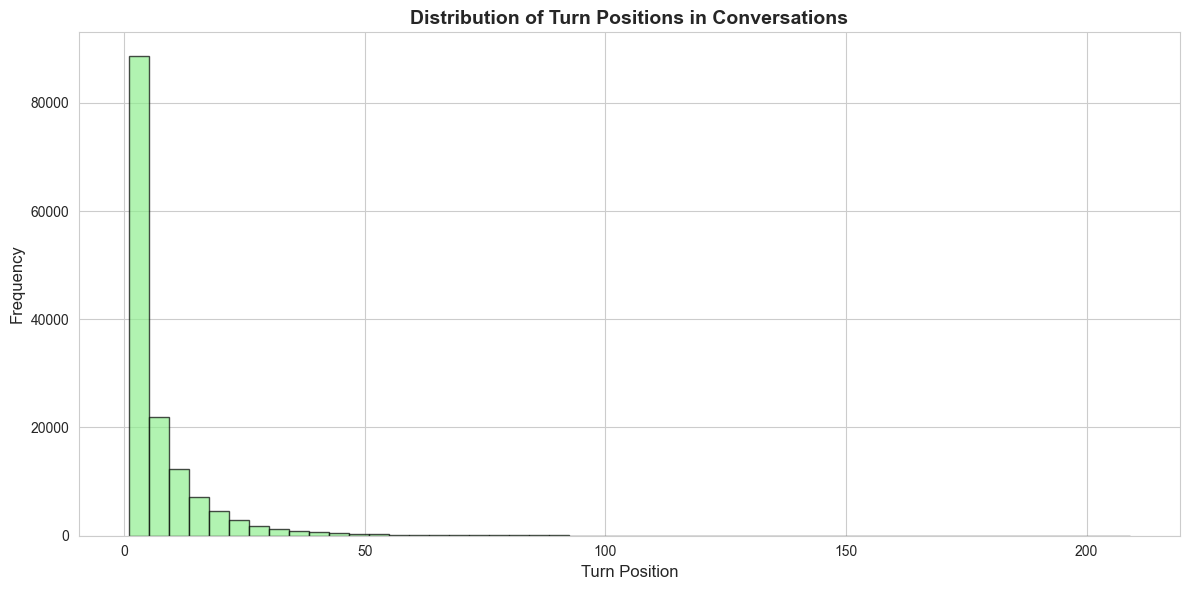

In [ ]:
# Distribution of turn positions
position_counts = df['turn_number'].value_counts().sort_index()
position_percentages = (position_counts / len(df) * 100).round(2)

print("Turn Position Distribution:")
print("="*60)
print(f"{'Position':>8} {'Count':>10} {'Percentage':>12}")
print("-"*60)
# Show first 20 positions
for pos in sorted(position_counts.index)[:20]:
    count = position_counts[pos]
    pct = position_percentages[pos]
    print(f"{pos:>8} {count:>10} {pct:>11.2f}%")
if len(position_counts) > 20:
    print(f"{'...':>8} {'...':>10} {'...':>12}")
    # Show last few positions
    for pos in sorted(position_counts.index)[-3:]:
        count = position_counts[pos]
        pct = position_percentages[pos]
        print(f"{pos:>8} {count:>10} {pct:>11.2f}%")
print("-"*60)
print(f"{'Total':>8} {len(df):>10} {'100.00%':>12}")

print(f"\nSummary statistics:")
print(df['turn_number'].describe())

plt.figure(figsize=(12, 6))
plt.hist(df['turn_number'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('Distribution of Turn Positions in Conversations', fontsize=14, fontweight='bold')
plt.xlabel('Turn Position', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

### 5.4 Text Length Analysis


User Prompt Length Distribution (by character range):
          Range      Count   Percentage
------------------------------------------------------------
           0-50      60796       42.09%
         51-100      35222       24.39%
        101-200      23138       16.02%
        201-500      16500       11.42%
       501-1000       5635        3.90%
      1001-2000       2198        1.52%
      2001-5000        852        0.59%
          5000+         98        0.07%
------------------------------------------------------------
          Total     144439      100.00%

LLM Response Length Distribution (by character range):
          Range      Count   Percentage
------------------------------------------------------------
           0-50      14099        9.76%
         51-100      10909        7.55%
        101-200      14703       10.18%
        201-500      27091       18.76%
       501-1000      27615       19.12%
      1001-2000      31215       21.61%
      2001-5000      18570

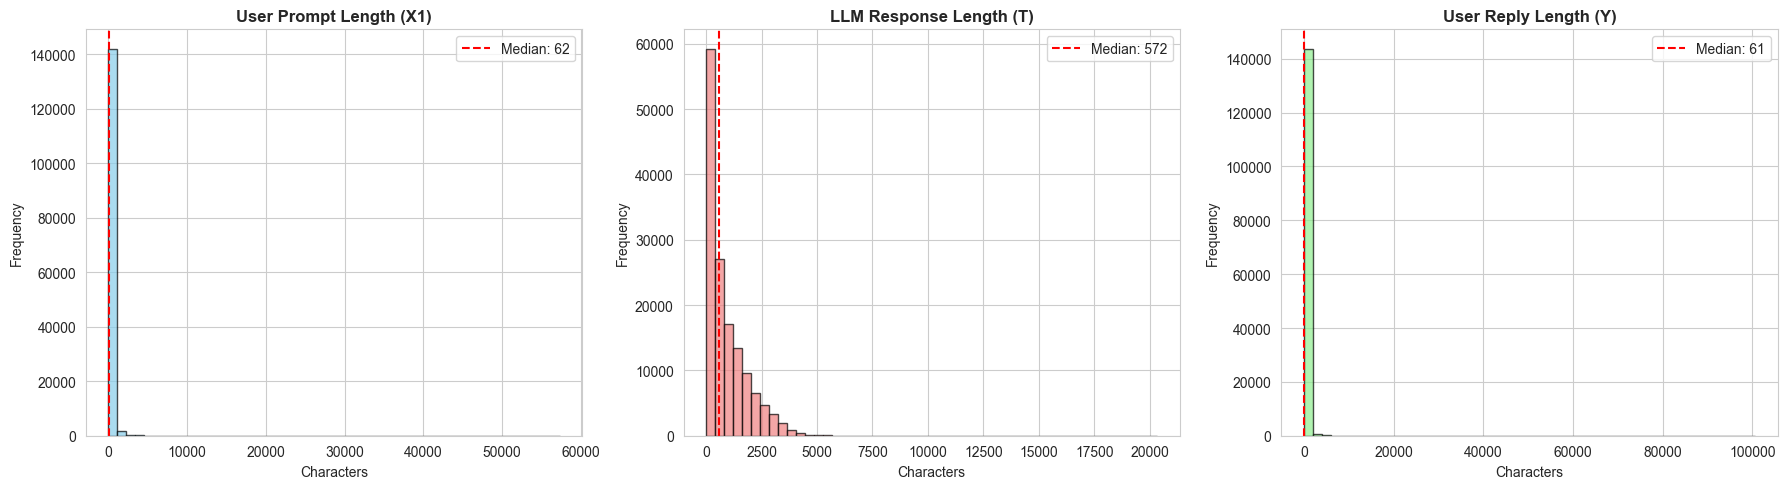

In [ ]:
# Calculate text lengths
df['user_prompt_length'] = df['user_prompt'].str.len()
df['llm_response_length'] = df['llm_response'].str.len()
df['user_reply_length'] = df['user_reply'].str.len()

# Create frequency bins for text lengths
def create_length_bins(series, name):
    bins = [0, 50, 100, 200, 500, 1000, 2000, 5000, float('inf')]
    labels = ['0-50', '51-100', '101-200', '201-500', '501-1000', '1001-2000', '2001-5000', '5000+']
    binned = pd.cut(series, bins=bins, labels=labels, include_lowest=True)
    counts = binned.value_counts().sort_index()
    percentages = (counts / len(series) * 100).round(2)
    
    print(f"\n{name} Length Distribution (by character range):")
    print("="*60)
    print(f"{'Range':>15} {'Count':>10} {'Percentage':>12}")
    print("-"*60)
    for label, count in counts.items():
        pct = percentages[label]
        print(f"{label:>15} {count:>10} {pct:>11.2f}%")
    print("-"*60)
    print(f"{'Total':>15} {len(series):>10} {'100.00%':>12}")

create_length_bins(df['user_prompt_length'], "User Prompt")
create_length_bins(df['llm_response_length'], "LLM Response")
create_length_bins(df['user_reply_length'], "User Reply")

print("\n" + "="*60)
print("Detailed Statistics:")
print("="*60)
print("\nUser Prompt Length:")
print(df['user_prompt_length'].describe())
print("\nLLM Response Length:")
print(df['llm_response_length'].describe())
print("\nUser Reply Length:")
print(df['user_reply_length'].describe())

# Plot text length distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['user_prompt_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('User Prompt Length (X1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Characters', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df['user_prompt_length'].median(), color='red', linestyle='--', label=f'Median: {df["user_prompt_length"].median():.0f}')
axes[0].legend()

axes[1].hist(df['llm_response_length'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title('LLM Response Length (T)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Characters', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].axvline(df['llm_response_length'].median(), color='red', linestyle='--', label=f'Median: {df["llm_response_length"].median():.0f}')
axes[1].legend()

axes[2].hist(df['user_reply_length'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].set_title('User Reply Length (Y)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Characters', fontsize=10)
axes[2].set_ylabel('Frequency', fontsize=10)
axes[2].axvline(df['user_reply_length'].median(), color='red', linestyle='--', label=f'Median: {df["user_reply_length"].median():.0f}')
axes[2].legend()

plt.tight_layout()
plt.show()

### 5.5 User Activity Distribution

User Activity Distribution (Turn Pairs per User):
  Turn Pairs      Users   Percentage
------------------------------------------------------------
           1      15001       44.04%
           2       6509       19.11%
         3-4       5641       16.56%
         5-9       4192       12.31%
       10-19       1766        5.18%
       20-49        734        2.15%
         50+        218        0.64%
------------------------------------------------------------
       Total      34061      100.00%

Summary statistics:
count    34061.000000
mean         4.240598
std         14.209042
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max       1121.000000
Name: count, dtype: float64

Key insights:
  - Users with only 1 turn pair: 15,001 (44.04%)
  - Users with 2-5 turn pairs: 13,576
  - Users with 6-10 turn pairs: 3,145
  - Users with >10 turn pairs: 2,339 (6.87%)
  - Most active user: 1121 turn pairs


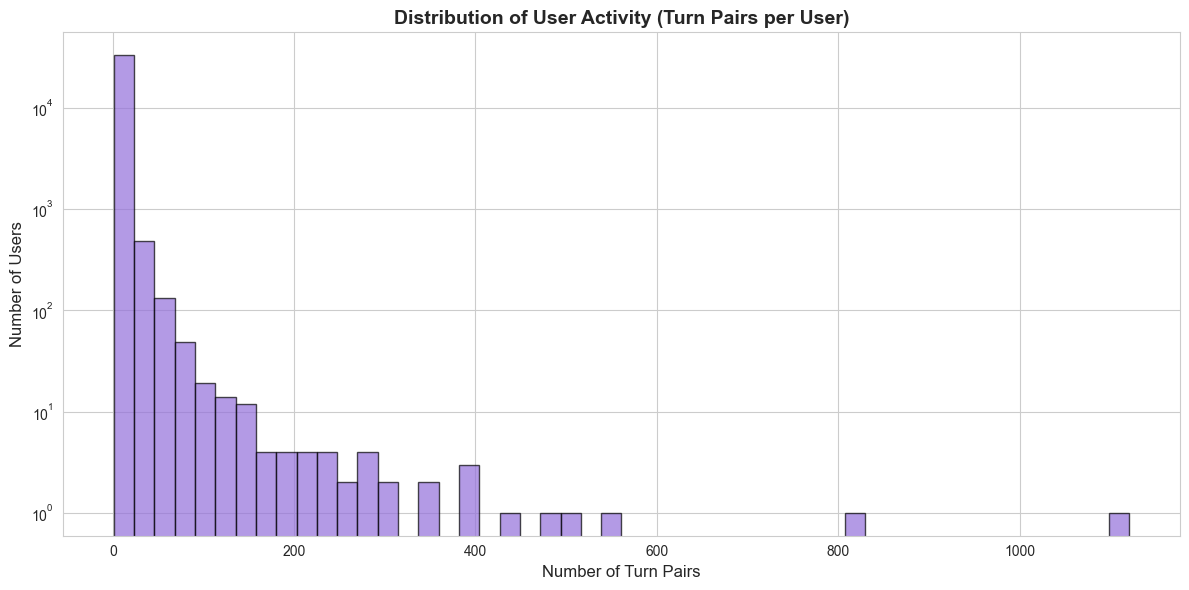

In [ ]:
# User activity (number of turn pairs per user)
user_activity = df['user_id'].value_counts()

# Create activity bins
activity_bins = [1, 2, 3, 5, 10, 20, 50, float('inf')]
activity_labels = ['1', '2', '3-4', '5-9', '10-19', '20-49', '50+']
binned_activity = pd.cut(user_activity, bins=activity_bins, labels=activity_labels, include_lowest=True, right=False)
activity_counts = binned_activity.value_counts().sort_index()
activity_percentages = (activity_counts / len(user_activity) * 100).round(2)

print("User Activity Distribution (Turn Pairs per User):")
print("="*60)
print(f"{'Turn Pairs':>12} {'Users':>10} {'Percentage':>12}")
print("-"*60)
for label, count in activity_counts.items():
    pct = activity_percentages[label]
    print(f"{label:>12} {count:>10} {pct:>11.2f}%")
print("-"*60)
print(f"{'Total':>12} {len(user_activity):>10} {'100.00%':>12}")

print(f"\nSummary statistics:")
print(user_activity.describe())

print(f"\nKey insights:")
print(f"  - Users with only 1 turn pair: {(user_activity == 1).sum():,} ({(user_activity == 1).sum()/len(user_activity)*100:.2f}%)")
print(f"  - Users with 2-5 turn pairs: {((user_activity >= 2) & (user_activity <= 5)).sum():,}")
print(f"  - Users with 6-10 turn pairs: {((user_activity >= 6) & (user_activity <= 10)).sum():,}")
print(f"  - Users with >10 turn pairs: {(user_activity > 10).sum():,} ({(user_activity > 10).sum()/len(user_activity)*100:.2f}%)")
print(f"  - Most active user: {user_activity.max()} turn pairs")

plt.figure(figsize=(12, 6))
plt.hist(user_activity, bins=50, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.title('Distribution of User Activity (Turn Pairs per User)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Turn Pairs', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.yscale('log')
plt.tight_layout()
plt.show()

### 5.6 Geographic Distribution

Geographic Distribution (Top 20 Countries):
Country                               Count   Percentage   Cumulative
----------------------------------------------------------------------
 1. United States                      36355       25.17%       25.17%
 2. Russia                              8878        6.15%       31.32%
 3. India                               8066        5.58%       36.90%
 4. United Kingdom                      7425        5.14%       42.04%
 5. Canada                              5973        4.14%       46.18%
 6. Hong Kong                           5504        3.81%       49.99%
 7. China                               5403        3.74%       53.73%
 8. Philippines                         4664        3.23%       56.96%
 9. Egypt                               4081        2.83%       59.79%
10. Australia                           3883        2.69%       62.48%
11. Germany                             3432        2.38%       64.86%
12. France                        

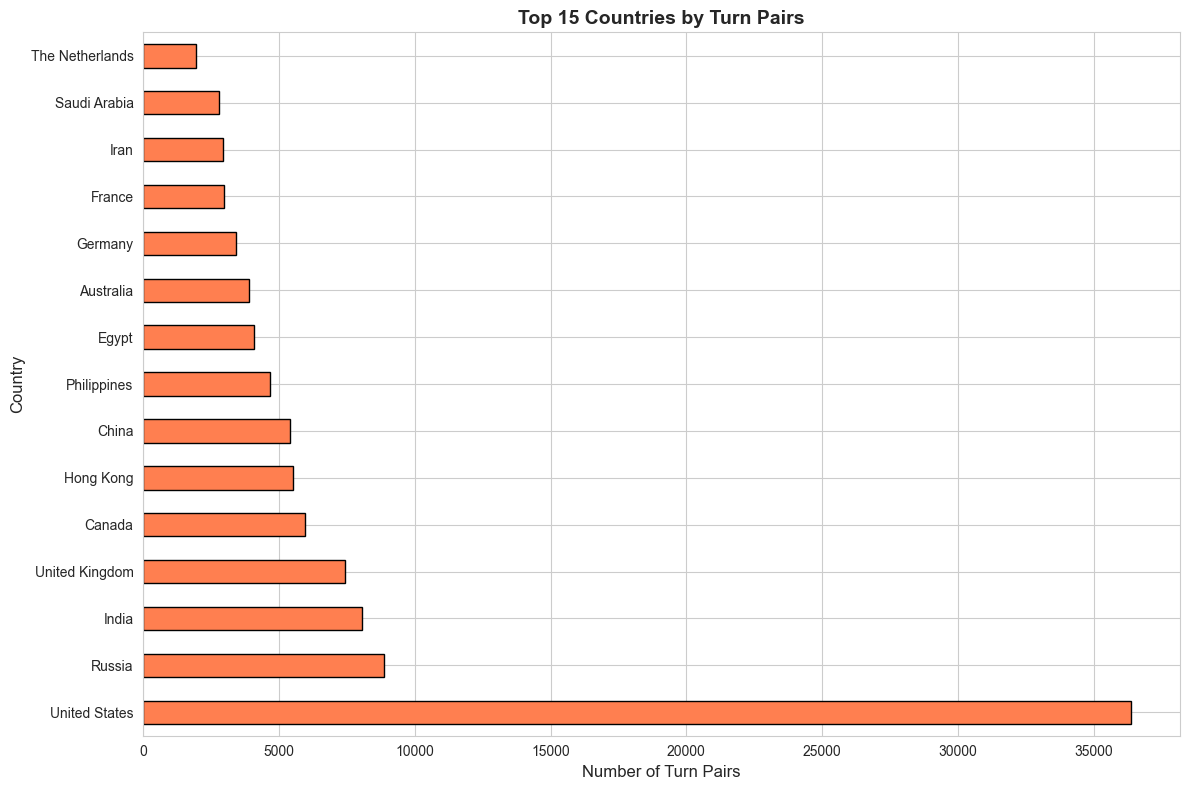

In [ ]:
# Top countries
country_counts = df['country'].value_counts()
country_percentages = (country_counts / len(df) * 100).round(2)

print("Geographic Distribution (Top 20 Countries):")
print("="*70)
print(f"{'Country':<30} {'Count':>12} {'Percentage':>12} {'Cumulative':>12}")
print("-"*70)
cumulative = 0
for i, (country, count) in enumerate(country_counts.head(20).items(), 1):
    pct = country_percentages[country]
    cumulative += pct
    print(f"{i:2d}. {country:<27} {count:>12} {pct:>11.2f}% {cumulative:>11.2f}%")
print("-"*70)
other_countries = len(country_counts) - 20
if other_countries > 0:
    other_count = country_counts.iloc[20:].sum()
    other_pct = (other_count / len(df) * 100)
    print(f"    {'Other (' + str(other_countries) + ' countries)':<27} {other_count:>12} {other_pct:>11.2f}% {'100.00%':>12}")
    print("-"*70)
print(f"{'Total':<30} {len(df):>12} {'100.00%':>12}")

print(f"\nGeographic coverage:")
print(f"  - Total unique countries: {len(country_counts)}")
print(f"  - Top 5 countries account for: {country_percentages.head(5).sum():.2f}%")
print(f"  - Top 10 countries account for: {country_percentages.head(10).sum():.2f}%")

plt.figure(figsize=(12, 8))
top_15 = country_counts.head(15)
top_15.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Top 15 Countries by Turn Pairs', fontsize=14, fontweight='bold')
plt.xlabel('Number of Turn Pairs', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

### 5.7 Data Quality Checks

In [ ]:
# Check for empty content
print("\n" + "="*50)
print("Empty content check:")
print(f"Empty user prompts: {(df['user_prompt'].str.len() == 0).sum()}")
print(f"Empty LLM responses: {(df['llm_response'].str.len() == 0).sum()}")
print(f"Empty user replies: {(df['user_reply'].str.len() == 0).sum()}")

# Check for missing values
print("\n" + "="*50)
print("Missing values:")
print(df.isnull().sum())


Empty content check:
Empty user prompts: 1962
Empty LLM responses: 0
Empty user replies: 1938

Missing values:
conversation_hash        0
turn_pair_id             0
model                    0
user_id                  0
turn_number              0
total_turns              0
timestamp                0
hour_of_day              0
user_prompt              0
llm_response             0
user_reply               0
turn_identifier          0
hashed_ip                0
country                168
user_prompt_length       0
llm_response_length      0
user_reply_length        0
dtype: int64
Empty user replies: 1938

Missing values:
conversation_hash        0
turn_pair_id             0
model                    0
user_id                  0
turn_number              0
total_turns              0
timestamp                0
hour_of_day              0
user_prompt              0
llm_response             0
user_reply               0
turn_identifier          0
hashed_ip                0
country                

## 6. Summary

### Key Takeaways:

1. **Preprocessing Complete**: Successfully filtered and flattened the WildChat-1M dataset
2. **Data Structure**: Each row now represents a turn-pair with:
   - **T (Treatment)**: LLM's response (to be scored for empathy)
   - **Y (Outcome)**: User's subsequent reply (to be scored for attachment)
   - **X1 (Confounder)**: User's initial prompt
   - **X2 (Confounder)**: User ID (latent traits)
   - **X3 (Confounder)**: Conversation context (turn position, length, timestamp)
   - **X4 (Confounder)**: Model ID

### Next Steps:

1. **LLM-as-a-Judge Scoring**: Apply empathy scoring to `llm_response` and attachment scoring to `user_reply`
2. **Embedding Generation**: Create embeddings for `user_prompt` (X1) for matching
3. **Propensity Score Matching**: Use the confounders to create matched pairs
4. **Causal Analysis**: Estimate the effect of LLM empathy on user attachment

In [ ]:
print("\n" + "="*70)
print("PREPROCESSING COMPLETE!")
print("="*70)
print(f"\n✓ Sample dataset saved to: {sample_output_path}")
print(f"  - Rows: {len(df_sample_processed):,}")
print(f"  - Size: {os.path.getsize(sample_output_path) / (1024*1024):.2f} MB")
print(f"\n✓ Full dataset saved to: {full_output_path}")
print(f"  - Rows: {len(df_full_processed):,}")
print(f"  - Size: {os.path.getsize(full_output_path) / (1024*1024):.2f} MB")
print("\n" + "="*70)


PREPROCESSING COMPLETE!

✓ Sample dataset saved to: ../data/filtered/wildchat_sample_preprocessed.csv
  - Rows: 223
  - Size: 0.33 MB

✓ Full dataset saved to: ../data/filtered/wildchat_full_preprocessed.csv
  - Rows: 144,439
  - Size: 202.57 MB

